# Corruption and Inflation: A Country-Year Analysis

## Data Preparation and Tidying

This project investigates the relationship between inflation and control of corruption across countries and years.

The raw data comes from:
- World Bank inflation data
- World Bank country metadata
- Worldwide Governance Indicators control of corruption data

The goal of this section is to clean and combine the raw datasets into one tidy country-year dataset.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
import plotly.io as pio

pio.templates.default = "plotly_white"

In [ ]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

inflation_path = DATA_DIR / "API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_4522.csv"

metadata_path = (
    DATA_DIR
    / "Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_4522.csv"
)

wgi_path = DATA_DIR / "wgidataset_with_sourcedata-2025.xlsx"

In [3]:
inflation_raw = pd.read_csv(inflation_path, skiprows=4, encoding="utf-8-sig")

metadata_raw = pd.read_csv(metadata_path, encoding="utf-8-sig")

wgi_raw = pd.read_excel(wgi_path, sheet_name="cc")

In [4]:
with open(inflation_path, "r", encoding="utf-8-sig") as file:
    for _ in range(6):
        print(repr(file.readline()))

'"Data Source","World Development Indicators",\n'
'\n'
'"Last Updated Date","2026-07-01",\n'
'\n'
'"Country Name","Country Code","Indicator Name","Indicator Code","1960","1961","1962","1963","1964","1965","1966","1967","1968","1969","1970","1971","1972","1973","1974","1975","1976","1977","1978","1979","1980","1981","1982","1983","1984","1985","1986","1987","1988","1989","1990","1991","1992","1993","1994","1995","1996","1997","1998","1999","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025",\n'
'"Aruba","ABW","Inflation, consumer prices (annual %)","FP.CPI.TOTL.ZG","","","","","","","","","","","","","","","","","","","","","","","","","","4.03225805628628","1.07396640826828","3.64304545817705","3.12186849610722","3.99162804604575","5.83668775158165","5.55555555555579","3.87337536996479","5.2155599603571","6.31107971270439","3.36139107320898","3.2252879721397

In [5]:
inflation_raw.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,4.270111,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,1.657818,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020,NaN


In [6]:
metadata_raw.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [7]:
wgi_raw.head()

,ID variable (economy code/ gov. dimension/ year),Economy (name),Economy (code),Region,Income classification,Year,Governance dimension,Number of sources,Governance estimate (approx. -2.5 to +2.5),Standard error (estimate),...,OBI mean,PIA mean,PRS mean,RSF mean,VAB mean,VDM mean,WBS mean,WCY mean,WJP mean,WMO mean
0,ADOcc1996,Andorra,ADO,NaN,NaN,1996,cc,1,1.362621,0.435253,...,..,..,..,..,..,..,..,..,..,0.875
1,AFGcc1996,Afghanistan,AFG,South Asia,Low income,1996,cc,2,-1.717570,0.343049,...,..,..,..,..,..,0.148,..,..,..,0
2,AGOcc1996,Angola,AGO,Sub-Saharan Africa,Lower middle income,1996,cc,4,-1.116075,0.231675,...,..,..,0.5,..,..,0.191,..,..,..,0.125
3,ALBcc1996,Albania,ALB,Europe & Central Asia,Upper middle income,1996,cc,3,-0.837552,0.295562,...,..,..,0.333333,..,..,0.317,..,..,..,0.25
4,AREcc1996,United Arab Emirates,ARE,Middle East & North Africa,High income,1996,cc,4,0.241391,0.231675,...,..,..,0.333333,..,..,0.865,..,..,..,0.75


In [8]:
inflation_raw.shape, metadata_raw.shape, wgi_raw.shape

((265, 71), (264, 6), (5373, 51))

In [9]:
inflation_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            70 non-null     float64
 5   1961            72 non-null     float64
 6   1962            74 non-null     float64
 7   1963            74 non-null     float64
 8   1964            79 non-null     float64
 9   1965            86 non-null     float64
 10  1966            93 non-null     float64
 11  1967            100 non-null    float64
 12  1968            101 non-null    float64
 13  1969            102 non-null    float64
 14  1970            108 non-null    float64
 15  1971            112 non-null    float64
 16  1972            114 non-null    float64
 17  1973            117 non-null    flo

In [10]:
inflation_raw.isna().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              195
                 ... 
2022               40
2023               42
2024               44
2025               54
Unnamed: 70       265
Length: 71, dtype: int64

In [11]:
inflation_clean = inflation_raw.drop(columns=["Unnamed: 70"])

In [12]:
inflation_clean.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.931196,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.446877,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,4.270111
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,1.657818
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020


In [13]:
year_columns = [col for col in inflation_clean.columns if col.isdigit()]

inflation_long = inflation_clean.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_columns,
    var_name="year",
    value_name="inflation"
)

In [14]:
inflation_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,inflation
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN


In [15]:
inflation_long = inflation_long.rename(
    columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    }
)

inflation_long["year"] = inflation_long["year"].astype(int)

In [16]:
inflation_long = inflation_long.dropna(subset=["inflation"]).reset_index(drop=True)

inflation_long.head()

,country_name,country_code,indicator_name,indicator_code,year,inflation
0,Australia,AUS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,3.728822
1,Austria,AUT,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.945749
2,Belgium,BEL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,0.299467
3,Burkina Faso,BFA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,7.788162
4,Bolivia,BOL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,11.533153


In [17]:
inflation_long = inflation_long.drop(columns=["indicator_name", "indicator_code"])

inflation_long.head()

#removed unneccesary columns because they add nothing and they don't change for country or inflation value

,country_name,country_code,year,inflation
0,Australia,AUS,1960,3.728822
1,Austria,AUT,1960,1.945749
2,Belgium,BEL,1960,0.299467
3,Burkina Faso,BFA,1960,7.788162
4,Bolivia,BOL,1960,11.533153


## Tidying the country metadata

The country metadata will be used to add regional and income-group categories and to distinguish actual countries from aggregate groups such as “World” and “High income”.

In [18]:
metadata_raw.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [19]:
metadata_raw.columns

Index(['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName',
       'Unnamed: 5'],
      dtype='object')

In [20]:
metadata_clean = metadata_raw.rename(
    columns={
        "Country Code": "country_code",
        "Region": "region",
        "IncomeGroup": "income_level",
        "TableName": "country_name_metadata"
    }
)

In [21]:
metadata_clean = metadata_clean[
    [
        "country_code",
        "country_name_metadata",
        "region",
        "income_level"
    ]
].copy()

metadata_clean.head()

,country_code,country_name_metadata,region,income_level
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,NaN,NaN
2,AFG,Afghanistan,Middle East & North Africa,Low income
3,AFW,Africa Western and Central,NaN,NaN
4,AGO,Angola,Sub-Saharan Africa,Lower middle income


In [22]:
metadata_clean[metadata_clean["region"].isna()].head(20)

,country_code,country_name_metadata,region,income_level
1,AFE,Africa Eastern and Southern,NaN,NaN
3,AFW,Africa Western and Central,NaN,NaN
7,ARB,Arab World,NaN,NaN
36,CEB,Central Europe and the Baltics,NaN,NaN
49,CSS,Caribbean small states,NaN,NaN
61,EAP,East Asia & Pacific (excluding high income),NaN,NaN
62,EAR,Early-demographic dividend,NaN,NaN
63,EAS,East Asia & Pacific,NaN,NaN
64,ECA,Europe & Central Asia (excluding high income),NaN,NaN
65,ECS,Europe & Central Asia,NaN,NaN


In [23]:
metadata_clean = (
    metadata_clean
    .dropna(subset=["region"])
    .reset_index(drop=True)
)

metadata_clean.head()

,country_code,country_name_metadata,region,income_level
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFG,Afghanistan,Middle East & North Africa,Low income
2,AGO,Angola,Sub-Saharan Africa,Lower middle income
3,ALB,Albania,Europe & Central Asia,Upper middle income
4,AND,Andorra,Europe & Central Asia,High income


In [24]:
metadata_clean.shape

(217, 4)

In [25]:
inflation_tidy = inflation_long.merge(
    metadata_clean,
    on="country_code",
    how="inner"
)

In [26]:
inflation_tidy.head()

,country_name,country_code,year,inflation,country_name_metadata,region,income_level
0,Australia,AUS,1960,3.728822,Australia,East Asia & Pacific,High income
1,Austria,AUT,1960,1.945749,Austria,Europe & Central Asia,High income
2,Belgium,BEL,1960,0.299467,Belgium,Europe & Central Asia,High income
3,Burkina Faso,BFA,1960,7.788162,Burkina Faso,Sub-Saharan Africa,Low income
4,Bolivia,BOL,1960,11.533153,Bolivia,Latin America & Caribbean,Lower middle income


In [27]:
inflation_tidy = inflation_tidy.drop(columns=["country_name_metadata"])

inflation_tidy.head()

,country_name,country_code,year,inflation,region,income_level
0,Australia,AUS,1960,3.728822,East Asia & Pacific,High income
1,Austria,AUT,1960,1.945749,Europe & Central Asia,High income
2,Belgium,BEL,1960,0.299467,Europe & Central Asia,High income
3,Burkina Faso,BFA,1960,7.788162,Sub-Saharan Africa,Low income
4,Bolivia,BOL,1960,11.533153,Latin America & Caribbean,Lower middle income


In [28]:
inflation_tidy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9136 entries, 0 to 9135
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  9136 non-null   object 
 1   country_code  9136 non-null   object 
 2   year          9136 non-null   int64  
 3   inflation     9136 non-null   float64
 4   region        9136 non-null   object 
 5   income_level  9136 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 428.4+ KB


In [29]:
wgi_raw.head()

,ID variable (economy code/ gov. dimension/ year),Economy (name),Economy (code),Region,Income classification,Year,Governance dimension,Number of sources,Governance estimate (approx. -2.5 to +2.5),Standard error (estimate),...,OBI mean,PIA mean,PRS mean,RSF mean,VAB mean,VDM mean,WBS mean,WCY mean,WJP mean,WMO mean
0,ADOcc1996,Andorra,ADO,NaN,NaN,1996,cc,1,1.362621,0.435253,...,..,..,..,..,..,..,..,..,..,0.875
1,AFGcc1996,Afghanistan,AFG,South Asia,Low income,1996,cc,2,-1.717570,0.343049,...,..,..,..,..,..,0.148,..,..,..,0
2,AGOcc1996,Angola,AGO,Sub-Saharan Africa,Lower middle income,1996,cc,4,-1.116075,0.231675,...,..,..,0.5,..,..,0.191,..,..,..,0.125
3,ALBcc1996,Albania,ALB,Europe & Central Asia,Upper middle income,1996,cc,3,-0.837552,0.295562,...,..,..,0.333333,..,..,0.317,..,..,..,0.25
4,AREcc1996,United Arab Emirates,ARE,Middle East & North Africa,High income,1996,cc,4,0.241391,0.231675,...,..,..,0.333333,..,..,0.865,..,..,..,0.75


In [30]:
wgi_raw.columns.tolist()

['ID variable (economy code/ gov. dimension/ year)',
 'Economy (name)',
 'Economy (code)',
 'Region',
 'Income classification',
 'Year',
 'Governance dimension',
 'Number of sources',
 'Governance estimate (approx. -2.5 to +2.5)',
 'Standard error (estimate)',
 'Lower threshold (90% conf. int. estimate)',
 'Upper threshold (90% conf. int. estimate)',
 'Governance score (0-100)',
 'Standard error (gov. score)',
 'Lower threshold (90% conf. int. score)',
 'Upper threshold (90% conf. int. score)',
 'ADB mean',
 'AFR mean',
 'ARB mean',
 'ASB mean',
 'ASD mean',
 'BPS mean',
 'BTI mean',
 'CCR mean',
 'EBR mean',
 'EIU mean',
 'EQI mean',
 'EUB mean',
 'FRH mean',
 'GCB mean',
 'GCS mean',
 'GII mean',
 'GWP mean',
 'HER mean',
 'HRM mean',
 'HUM mean',
 'IFD mean',
 'IJT mean',
 'IRP mean',
 'LBO mean',
 'MSI mean',
 'OBI mean',
 'PIA mean',
 'PRS mean',
 'RSF mean',
 'VAB mean',
 'VDM mean',
 'WBS mean',
 'WCY mean',
 'WJP mean',
 'WMO mean']

### Selecting relevant corruption variables

The WGI sheet contains many columns representing the individual sources used to calculate the governance indicator. For this analysis, I retained only the country, year, final corruption estimates, governance score, number of sources, and standard error.

A higher Control of Corruption score indicates stronger control of corruption, not more corruption.

In [31]:
wgi_raw["Governance dimension"].value_counts(dropna=False)

Governance dimension
cc    5373
Name: count, dtype: int64

In [32]:
wgi_clean = wgi_raw[
    [
        "Economy (name)",
        "Economy (code)",
        "Year",
        "Number of sources",
        "Governance estimate (approx. -2.5 to +2.5)",
        "Standard error (estimate)",
        "Governance score (0-100)"
    ]
].copy()

wgi_clean = wgi_clean.rename(
    columns={
        "Economy (name)": "country_name_wgi",
        "Economy (code)": "country_code",
        "Year": "year",
        "Number of sources": "corruption_sources",
        "Governance estimate (approx. -2.5 to +2.5)": "corruption_estimate",
        "Standard error (estimate)": "corruption_standard_error",
        "Governance score (0-100)": "corruption_score"
    }
)

wgi_clean.head()

,country_name_wgi,country_code,year,corruption_sources,corruption_estimate,corruption_standard_error,corruption_score
0,Andorra,ADO,1996,1,1.362621,0.435253,75.436374
1,Afghanistan,AFG,1996,2,-1.717570,0.343049,13.088573
2,Angola,AGO,1996,4,-1.116075,0.231675,25.263751
3,Albania,ALB,1996,3,-0.837552,0.295562,30.901500
4,United Arab Emirates,ARE,1996,4,0.241391,0.231675,52.740958


In [33]:
wgi_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373 entries, 0 to 5372
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_name_wgi           5373 non-null   object 
 1   country_code               5373 non-null   object 
 2   year                       5373 non-null   int64  
 3   corruption_sources         5373 non-null   int64  
 4   corruption_estimate        5373 non-null   float64
 5   corruption_standard_error  5373 non-null   float64
 6   corruption_score           5373 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 294.0+ KB


In [34]:
print("Inflation duplicates:",
    inflation_tidy.duplicated(subset=["country_code", "year"]).sum())

print( "WGI duplicates:",
    wgi_clean.duplicated(subset=["country_code", "year"]).sum())

Inflation duplicates: 0
WGI duplicates: 0


In [35]:
df = inflation_tidy.merge(
    wgi_clean,
    on=["country_code", "year"],
    how="inner",
    validate="one_to_one"
)

df.head()

,country_name,country_code,year,inflation,region,income_level,country_name_wgi,corruption_sources,corruption_estimate,corruption_standard_error,corruption_score
0,Angola,AGO,1996,4145.105982,Sub-Saharan Africa,Lower middle income,Angola,4,-1.116075,0.231675,25.263751
1,Albania,ALB,1996,12.725478,Europe & Central Asia,Upper middle income,Albania,3,-0.837552,0.295562,30.901500
2,Armenia,ARM,1996,18.681186,Europe & Central Asia,Upper middle income,Armenia,2,-0.572318,0.343049,36.270225
3,Australia,AUS,1996,2.615379,East Asia & Pacific,High income,Australia,6,2.150333,0.199662,91.380867
4,Austria,AUT,1996,1.860971,Europe & Central Asia,High income,Austria,6,1.930123,0.199662,86.923473


In [36]:
df.shape

(4585, 11)

In [37]:
name_differences = df.loc[
    df["country_name"] != df["country_name_wgi"],
    ["country_code", "country_name", "country_name_wgi"]
].drop_duplicates()

name_differences

,country_code,country_name,country_name_wgi
27,CIV,Cote d'Ivoire,Côte d’Ivoire
141,TUR,Turkiye,Türkiye
281,STP,Sao Tome and Principe,São Tomé and Príncipe


In [38]:
country_name_corrections = {
    "CIV": "Côte d’Ivoire",
    "TUR": "Türkiye",
    "STP": "São Tomé and Príncipe"
}

df["country_name"] = df["country_code"].map(country_name_corrections).fillna(
    df["country_name"]
)

In [39]:
df = df.drop(columns=["country_name_wgi"])

df.head()

,country_name,country_code,year,inflation,region,income_level,corruption_sources,corruption_estimate,corruption_standard_error,corruption_score
0,Angola,AGO,1996,4145.105982,Sub-Saharan Africa,Lower middle income,4,-1.116075,0.231675,25.263751
1,Albania,ALB,1996,12.725478,Europe & Central Asia,Upper middle income,3,-0.837552,0.295562,30.901500
2,Armenia,ARM,1996,18.681186,Europe & Central Asia,Upper middle income,2,-0.572318,0.343049,36.270225
3,Australia,AUS,1996,2.615379,East Asia & Pacific,High income,6,2.150333,0.199662,91.380867
4,Austria,AUT,1996,1.860971,Europe & Central Asia,High income,6,1.930123,0.199662,86.923473


In [40]:
df.loc[
    df["country_code"].isin(["CIV", "TUR", "STP"]),
    ["country_code", "country_name"]
].drop_duplicates()

,country_code,country_name
27,CIV,Côte d’Ivoire
141,TUR,Türkiye
281,STP,São Tomé and Príncipe


## Final Data Quality Checks

Before beginning the analysis, I checked the merged dataset for missing values, duplicate country-year observations, and the available year and country coverage.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4585 entries, 0 to 4584
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_name               4585 non-null   object 
 1   country_code               4585 non-null   object 
 2   year                       4585 non-null   int64  
 3   inflation                  4585 non-null   float64
 4   region                     4585 non-null   object 
 5   income_level               4585 non-null   object 
 6   corruption_sources         4585 non-null   int64  
 7   corruption_estimate        4585 non-null   float64
 8   corruption_standard_error  4585 non-null   float64
 9   corruption_score           4585 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 358.3+ KB


In [42]:
df.duplicated(subset=["country_code", "year"]).sum()

np.int64(0)

In [43]:
print("Rows:", len(df))
print("Countries:", df["country_code"].nunique())
print("First year:", df["year"].min())
print("Last year:", df["year"].max())

Rows: 4585
Countries: 190
First year: 1996
Last year: 2024


## Inspecting Numerical Distributions and Outliers

The merged dataset contains some historically extreme inflation observations. I inspected the numerical distributions and highest inflation values before deciding how to handle them in the visualizations.

In [44]:
df[
    [
        "inflation",
        "corruption_sources",
        "corruption_estimate",
        "corruption_standard_error",
        "corruption_score"
    ]
].describe().round(2)

,inflation,corruption_sources,corruption_estimate,corruption_standard_error,corruption_score
count,4585.00,4585.00,4585.00,4585.00,4585.00
mean,8.06,8.59,-0.02,0.21,47.45
std,64.54,3.61,0.99,0.07,20.05
min,-16.86,1.00,-2.06,0.15,6.06
25%,1.66,6.00,-0.78,0.17,32.10
50%,3.62,9.00,-0.25,0.19,42.89
75%,7.39,12.00,0.65,0.22,61.04
max,4145.11,15.00,2.48,0.98,98.13


In [45]:
df.nlargest(15, "inflation")[
    [
        "country_name",
        "country_code",
        "year",
        "inflation",
        "corruption_score"
    ]
]

,country_name,country_code,year,inflation,corruption_score
0,Angola,AGO,1996,4145.105982,25.263751
3878,Zimbabwe,ZWE,2020,557.201817,24.112562
336,"Congo, Dem. Rep.",COD,2000,513.906844,15.424314
29,"Congo, Dem. Rep.",COD,1996,492.441850,10.852608
3122,South Sudan,SSD,2016,379.999586,11.582900
4020,Sudan,SDN,2021,359.093041,21.692098
306,Angola,AGO,2000,324.996872,21.936965
3700,Zimbabwe,ZWE,2019,255.304991,21.877243
3147,"Venezuela, RB",VEN,2016,254.948535,19.195879
4327,Lebanon,LBN,2023,221.341644,22.443384


In [46]:
df["inflation_log"] = (
    np.sign(df["inflation"]) *
    np.log1p(np.abs(df["inflation"]))
)

#This is needed to give the really high values a logarithmic value so that we can look at inflation periods on visual graphs without deleteing data

### The original `inflation` variable will continue to be used whenever actual percentage values are important. The transformed `inflation_log` variable will only be used in visualizations where hyperinflation observations would otherwise make the relationship difficult to see.

### Handling extreme inflation values

The dataset contains several genuine hyperinflation observations. These values were retained in the original `inflation` column. To make visual comparisons easier without deleting information, I also created a signed logarithmic version of inflation.

In [47]:
df[
    [
        "country_name",
        "year",
        "inflation",
        "inflation_log"
    ]
].nlargest(15, "inflation")

,country_name,year,inflation,inflation_log
0,Angola,1996,4145.105982,8.329925
3878,Zimbabwe,2020,557.201817,6.324721
336,"Congo, Dem. Rep.",2000,513.906844,6.243986
29,"Congo, Dem. Rep.",1996,492.441850,6.201405
3122,South Sudan,2016,379.999586,5.942798
4020,Sudan,2021,359.093041,5.886362
306,Angola,2000,324.996872,5.786888
3700,Zimbabwe,2019,255.304991,5.546368
3147,"Venezuela, RB",2016,254.948535,5.544976
4327,Lebanon,2023,221.341644,5.404215


In [48]:
df.isna().sum()

country_name                 0
country_code                 0
year                         0
inflation                    0
region                       0
income_level                 0
corruption_sources           0
corruption_estimate          0
corruption_standard_error    0
corruption_score             0
inflation_log                0
dtype: int64

In [49]:
df = (
    df
    .sort_values(["country_name", "year"])
    .reset_index(drop=True)
)

In [50]:
df.head()

,country_name,country_code,year,inflation,region,income_level,corruption_sources,corruption_estimate,corruption_standard_error,corruption_score,inflation_log
0,Afghanistan,AFG,2005,12.686269,Middle East & North Africa,Low income,6,-1.571500,0.213525,16.045250,2.616393
1,Afghanistan,AFG,2006,6.784597,Middle East & North Africa,Low income,8,-1.522114,0.201638,17.044908,2.052147
2,Afghanistan,AFG,2007,8.680571,Middle East & North Africa,Low income,8,-1.569721,0.201638,16.081270,2.270121
3,Afghanistan,AFG,2008,26.418664,Middle East & North Africa,Low income,9,-1.612566,0.201007,15.214009,3.311224
4,Afghanistan,AFG,2009,-6.811161,Middle East & North Africa,Low income,8,-1.563103,0.201734,16.215216,-2.055554


## Saving the Tidy Dataset

The final merged dataset was sorted by country and year and exported as a CSV file. This cleaned file will also be used later in the Streamlit dashboard.

In [51]:
tidy_data_path = OUTPUT_DIR / "tidy_corruption_inflation.csv"

df.to_csv(tidy_data_path, index=False)

print("Saved to:", tidy_data_path)

Saved to: outputs/tidy_corruption_inflation.csv


# Exploratory Data Analysis and Visualizations

## Question 1: How many countries are represented in each region?

This visualization examines the geographical coverage of the merged dataset. Since every country appears in several years, I count unique country codes rather than the total number of rows.

In [52]:
region_counts = (
    df.groupby("region", as_index=False)
      .agg(country_count=("country_code", "nunique"))
      .sort_values("country_count", ascending=True)
)

region_counts

,region,country_count
4,North America,2
5,South Asia,6
3,Middle East & North Africa,23
0,East Asia & Pacific,30
2,Latin America & Caribbean,34
6,Sub-Saharan Africa,46
1,Europe & Central Asia,49


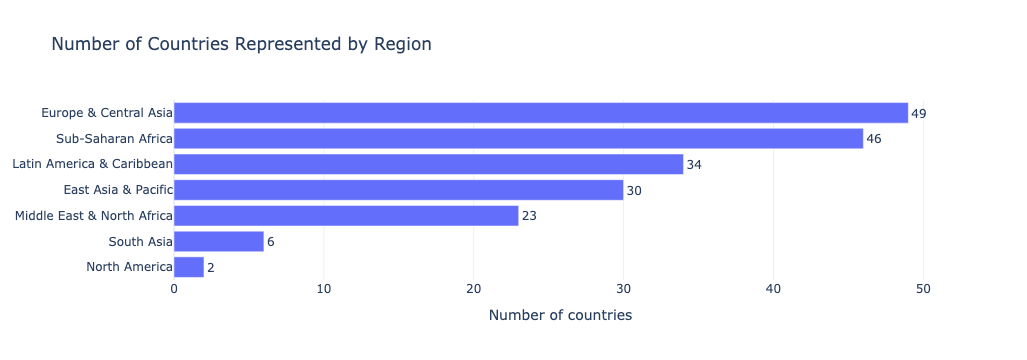

In [53]:
fig = px.bar(
    region_counts,
    x="country_count",
    y="region",
    orientation="h",
    text="country_count",
    title="Number of Countries Represented by Region",
    labels={
        "country_count": "Number of countries",
        "region": "Region"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    showlegend=False,
    yaxis_title=None
)

fig.show()

### Interpretation

The dataset provides broad international coverage, although the number of represented countries differs across regions. This should be considered when comparing regional averages because regions containing more countries contribute more observations to the full dataset.

## Question 2: What is the distribution of inflation across country year observations?

I first visualize the original annual inflation percentages. This allows me to determine whether extreme observations affect the readability and shape of the distribution.

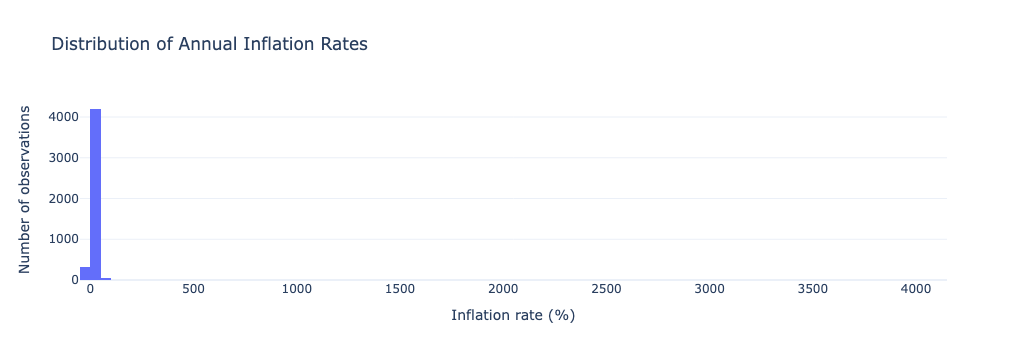

In [54]:
fig = px.histogram(
    df,
    x="inflation",
    nbins=100,
    title="Distribution of Annual Inflation Rates",
    labels={
        "inflation": "Inflation rate (%)"
    }
)

fig.update_layout(
    yaxis_title="Number of observations",
    showlegend=False
)

fig.show()

In [55]:
print("Original inflation skewness:", df["inflation"].skew())
print("Log-transformed skewness:", df["inflation_log"].skew())

Original inflation skewness: 57.98984361659286
Log-transformed skewness: -0.0053078406008977685


### Interpretation

The original distribution is extremely right skewed. Most country-year observations are concentrated near relatively low inflation rates, while a small number of hyperinflation episodes extend the horizontal axis to several thousand percent. As a result, the majority of observations are visually compressed near zero.

## Question 3 — Which country-year observations experienced the highest inflation? 

In [56]:
highest_inflation = (
    df.nlargest(15, "inflation")
      .sort_values("inflation", ascending=True)
)

fig = px.bar(
    highest_inflation,
    x="inflation",
    y="country_name",
    orientation="h",
    color="year",
    hover_data=["country_code", "corruption_score"],
    title="The 15 Highest Inflation Observations",
    labels={
        "inflation": "Inflation rate (%)",
        "country_name": "Country",
        "year": "Year",
        "corruption_score": "Control of corruption score"
    }
)

fig.update_layout(yaxis_title=None)

fig.show()

### TOP 15 highest inflation was observed by 9 different countries at seperate years also the right skew we saw in question 2 is mostly caused by angola and the other countries in this list. These observations appear to be genuine historical values, so removing them would discard meaningful information.

## Question 4 Can a transformation make the inflation distribution easier to examine without deleting extreme observations?

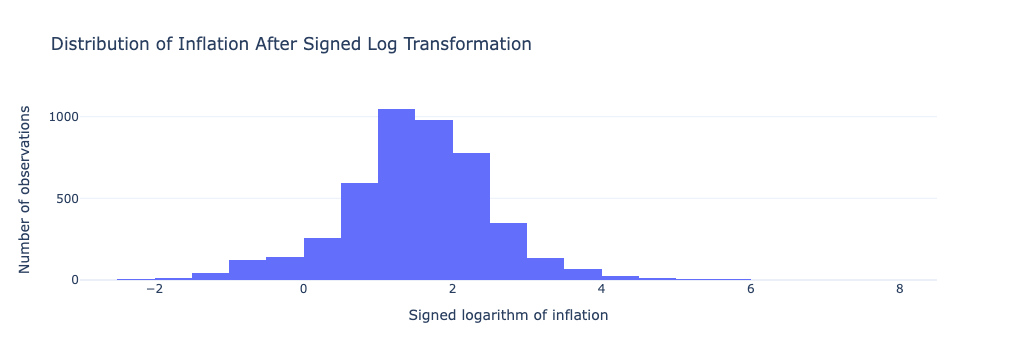

In [57]:
fig = px.histogram(
    df,
    x="inflation_log",
    nbins=50,
    title="Distribution of Inflation After Signed Log Transformation",
    labels={
        "inflation_log": "Signed logarithm of inflation"
    }
)

fig.update_layout(
    yaxis_title="Number of observations",
    showlegend=False
)

fig.show()

### Interpretation

The signed logarithmic transformation makes the complete inflation distribution much easier to examine. Extreme hyperinflation observations remain in the dataset, but they no longer compress the majority of observations into a narrow area. The transformed values are not percentages, so the original inflation variable will still be used whenever exact inflation rates are being interpreted.

## Question 5: How are Control of Corruption scores distributed?

Before comparing corruption control with inflation, I first examine how the corruption-control scores are distributed. A higher score represents stronger control of corruption, while a lower score represents weaker control.

In [59]:
df["corruption_score"].describe().round(2)

count    4585.00
mean       47.45
std        20.05
min         6.06
25%        32.10
50%        42.89
75%        61.04
max        98.13
Name: corruption_score, dtype: float64

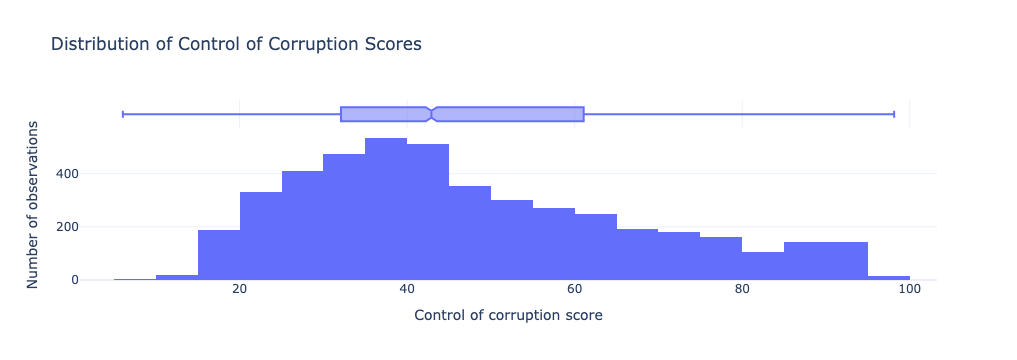

In [60]:
fig = px.histogram(
    df,
    x="corruption_score",
    nbins=40,
    marginal="box",
    title="Distribution of Control of Corruption Scores",
    labels={
        "corruption_score": "Control of corruption score"
    }
)

fig.update_layout(
    yaxis_title="Number of observations",
    showlegend=False
)

fig.show()

### Interpretation

Control of Corruption scores cover a broad range, from countries with very weak control to countries with very strong control. The median score is approximately 43 out of 100, indicating that half of the country-year observations fall below this level. This variation provides enough contrast to investigate whether inflation differs according to corruption control.

## Question 6: Is stronger control of corruption associated with lower inflation?

I compare the Control of Corruption score with the signed logarithm of inflation. The transformation is used because extreme hyperinflation observations would otherwise dominate the scatter plot.

In [62]:
pearson_original = df["corruption_score"].corr(
    df["inflation"],
    method="pearson"
)

pearson_transformed = df["corruption_score"].corr(
    df["inflation_log"],
    method="pearson"
)

spearman_correlation = df["corruption_score"].corr(
    df["inflation"],
    method="spearman"
)

correlation_results = pd.DataFrame({
    "measure": [
        "Pearson: original inflation",
        "Pearson: transformed inflation",
        "Spearman correlation"
    ],
    "correlation": [
        pearson_original,
        pearson_transformed,
        spearman_correlation
    ]
})

correlation_results.round(3)
#we do this to calculate correlation for both logarithmic and raw inflation values and using different methods

,measure,correlation
0,Pearson: original inflation,-0.077
1,Pearson: transformed inflation,-0.320
2,Spearman correlation,-0.369


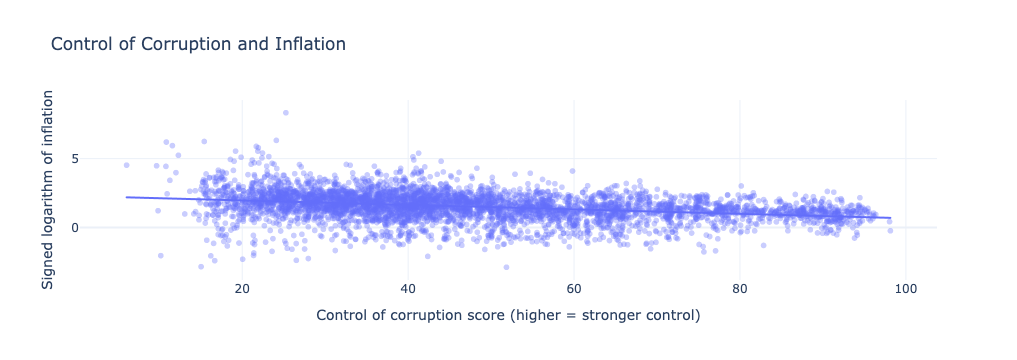

In [63]:
fig = px.scatter(
    df,
    x="corruption_score",
    y="inflation_log",
    opacity=0.35,
    trendline="ols",
    hover_name="country_name",
    hover_data=["year", "region", "income_level", "inflation"],
    title="Control of Corruption and Inflation",
    labels={
        "corruption_score": "Control of corruption score (higher = less corruption)",
        "inflation_log": "Signed logarithm of inflation",
        "year": "Year",
        "region": "Region",
        "income_level": "Income level",
        "inflation": "Inflation rate (%)"
    }
)

fig.show()

### Interpretation

The scatter plot shows that there is a slight negative correlation.

This indicates a weak negative association. However, there is substantial variation around the trend line, so corruption control alone does not explain inflation. This is a descriptive correlation and does not prove that corruption causes inflation.

## Question 7: How does median inflation differ between countries with weak and strong corruption control?

To make the comparison easier to interpret, I divide the observations into four equally sized groups based on their Control of Corruption scores. I use median inflation because the mean is highly affected by hyperinflation.

In [64]:
control_order = [
    "Very weak control",
    "Weak control",
    "Strong control",
    "Very strong control"
]

df["corruption_control_group"] = pd.qcut(
    df["corruption_score"],
    q=4,
    labels=control_order
)

In [65]:
control_summary = (
    df.groupby(
        "corruption_control_group",
        observed=True,
        as_index=False
    )
    .agg(
        median_inflation=("inflation", "median"),
        mean_corruption_score=("corruption_score", "mean"),
        observations=("inflation", "size")
    )
)

control_summary.round(2)

,corruption_control_group,median_inflation,mean_corruption_score,observations
0,Very weak control,6.10,24.91,1147
1,Weak control,4.55,37.69,1146
2,Strong control,3.29,51.00,1146
3,Very strong control,2.16,76.20,1146


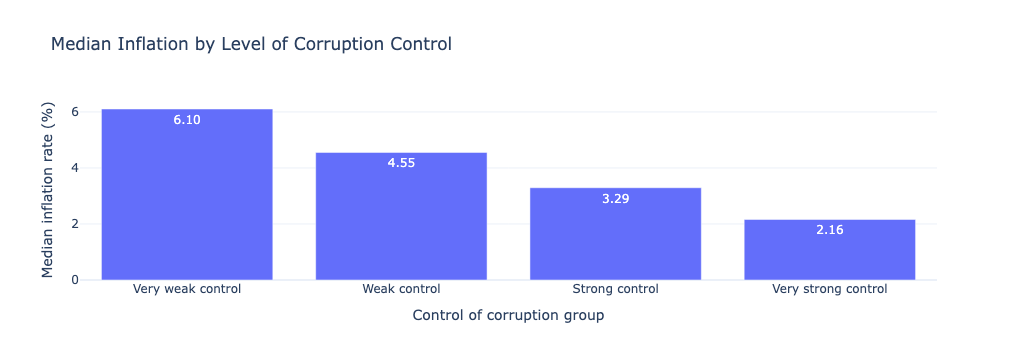

In [66]:
fig = px.bar(
    control_summary,
    x="corruption_control_group",
    y="median_inflation",
    text_auto=".2f",
    category_orders={
        "corruption_control_group": control_order
    },
    title="Median Inflation by Level of Corruption Control",
    labels={
        "corruption_control_group": "Control of corruption group",
        "median_inflation": "Median inflation rate (%)"
    }
)

fig.update_layout(showlegend=False)

fig.show()

### Interpretation

Median inflation decreases consistently as corruption control becomes stronger. The very weak control group has median inflation of approximately 6.1%, compared with approximately 2.16% in the very strong control group. This supports the negative relationship observed in the scatter plot, although other economic and institutional differences may also contribute to the pattern.

## Question 8: Does the relationship between corruption control and inflation differ by region?

The overall correlation may conceal regional differences. I therefore calculate a separate Spearman correlation for each region.

In [67]:
regional_correlations = pd.DataFrame([
    {
        "region": region,
        "spearman_correlation": group["corruption_score"].corr(
            group["inflation"],
            method="spearman"
        ),
        "observations": len(group)
    }
    for region, group in df.groupby("region")
])

regional_correlations = regional_correlations.sort_values(
    "spearman_correlation"
)

regional_correlations.round(3)

,region,spearman_correlation,observations
1,Europe & Central Asia,-0.437,1216
0,East Asia & Pacific,-0.419,693
3,Middle East & North Africa,-0.395,551
2,Latin America & Caribbean,-0.293,793
4,North America,-0.186,52
5,South Asia,-0.126,156
6,Sub-Saharan Africa,-0.079,1124


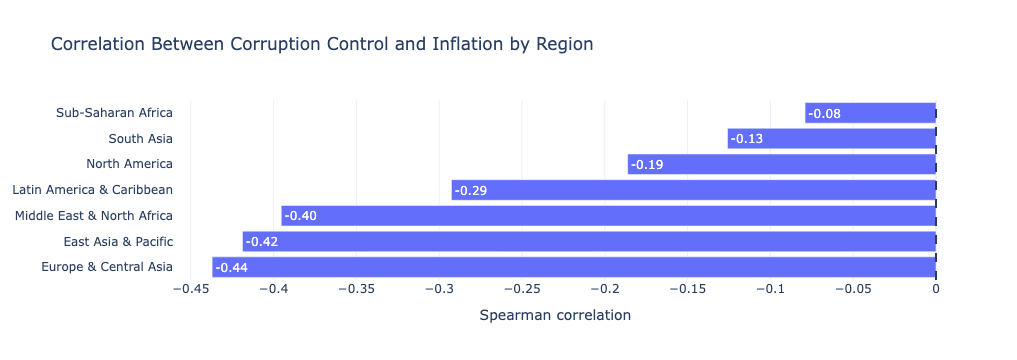

In [68]:
fig = px.bar(
    regional_correlations,
    x="spearman_correlation",
    y="region",
    orientation="h",
    text_auto=".2f",
    hover_data=["observations"],
    title="Correlation Between Corruption Control and Inflation by Region",
    labels={
        "spearman_correlation": "Spearman correlation",
        "region": "Region",
        "observations": "Number of observations"
    }
)

fig.add_vline(
    x=0,
    line_dash="dash"
)

fig.update_layout(yaxis_title=None)

fig.show()

### Interpretation

The relationship is negative in every region, but its strength differs considerably. The strongest negative associations appear in Europe and Central Asia, East Asia and the Pacific, and the Middle East and North Africa. The relationship is much weaker in Sub-Saharan Africa and South Asia so much so that if we analayzed Sub-Saharan Africa alone we would have said there is no correlation between corruption(or corruption control) and inflation.

This suggests that regional economic conditions and institutions influence the relationship between corruption control and inflation.

## Question 9: Has the relationship between corruption control and inflation changed over time?

I calculate the Spearman correlation separately for each year. This shows whether the negative association is consistent over the study period or only appears in particular years.

In [69]:
yearly_correlations = pd.DataFrame([
    {
        "year": year,
        "spearman_correlation": group["corruption_score"].corr(
            group["inflation"],
            method="spearman"
        ),
        "countries": group["country_code"].nunique()
    }
    for year, group in df.groupby("year")
])

yearly_correlations.head()

,year,spearman_correlation,countries
0,1996,-0.490892,153
1,1998,-0.399251,153
2,2000,-0.218526,157
3,2002,-0.361147,162
4,2003,-0.360362,165


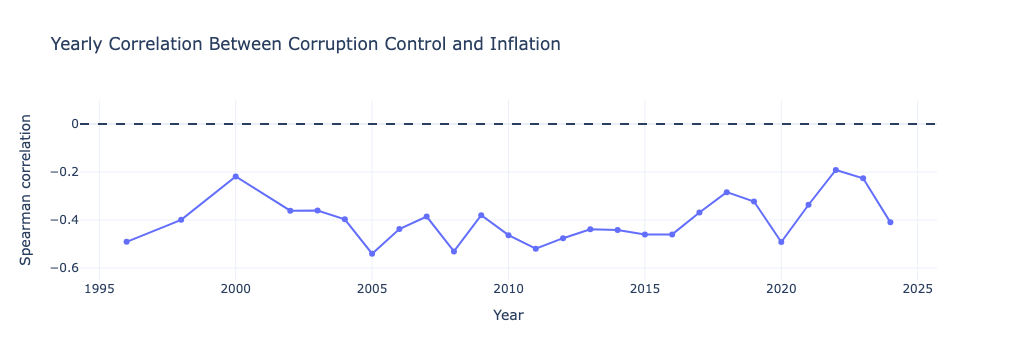

In [70]:
fig = px.line(
    yearly_correlations,
    x="year",
    y="spearman_correlation",
    markers=True,
    hover_data=["countries"],
    title="Yearly Correlation Between Corruption Control and Inflation",
    labels={
        "year": "Year",
        "spearman_correlation": "Spearman correlation",
        "countries": "Number of countries"
    }
)

fig.add_hline(
    y=0,
    line_dash="dash"
)

fig.update_yaxes(range=[-0.65, 0.1])

fig.show()

### Interpretation

The yearly correlations remain negative throughout the available period, although their strength changes from year to year. The negative association is particularly strong in some periods, while it becomes weaker in others. This indicates that the relationship is persistent but not constant and may be affected by global economic events, regional crises, and country-specific conditions.

## Question 10: Where is high inflation concentrated within the global economic hierarchy?

To bring the analysis together, I examine countries according to their region, income level, and level of corruption control.

The size of each rectangle represents the number of countries in the group, while the color represents median inflation. I use the latest available year to avoid counting the same country repeatedly across different years.

In [71]:
latest_year = df["year"].max()

latest_df = df[df["year"] == latest_year].copy()

print("Latest year:", latest_year)
print("Countries represented:", latest_df["country_code"].nunique())

Latest year: 2024
Countries represented: 174


In [72]:
latest_df["corruption_control_group"] = (
    latest_df["corruption_control_group"].astype(str)
)

hierarchy_data = (
    latest_df
    .groupby(
        [
            "region",
            "income_level",
            "corruption_control_group"
        ],
        as_index=False
    )
    .agg(
        country_count=("country_code", "nunique"),
        median_inflation=("inflation", "median"),
        median_corruption_score=("corruption_score", "median")
    )
)

hierarchy_data.head()

,region,income_level,corruption_control_group,country_count,median_inflation,median_corruption_score
0,East Asia & Pacific,High income,Strong control,2,1.452113,58.768234
1,East Asia & Pacific,High income,Very strong control,7,2.389511,79.677704
2,East Asia & Pacific,Lower middle income,Strong control,3,2.455451,45.018916
3,East Asia & Pacific,Lower middle income,Very weak control,3,0.808042,28.020227
4,East Asia & Pacific,Lower middle income,Weak control,1,2.062842,40.213296


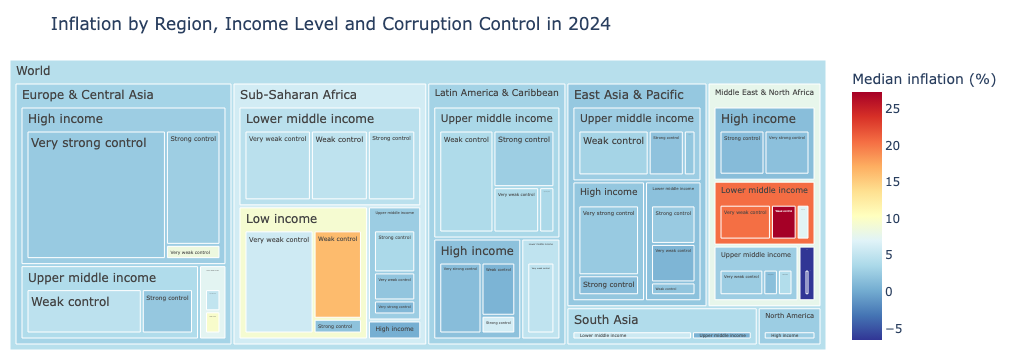

In [73]:
fig = px.treemap(
    hierarchy_data,
    path=[
        px.Constant("World"),
        "region",
        "income_level",
        "corruption_control_group"
    ],
    values="country_count",
    color="median_inflation",
    color_continuous_scale="RdYlBu_r",
    hover_data={
        "country_count": True,
        "median_inflation": ":.2f",
        "median_corruption_score": ":.2f"
    },
    title=(
        f"Inflation by Region, Income Level and "
        f"Corruption Control in {latest_year}"
    ),
    labels={
        "country_count": "Number of countries",
        "median_inflation": "Median inflation (%)",
        "median_corruption_score": "Median corruption-control score",
        "income_level": "Income level",
        "corruption_control_group": "Corruption-control group"
    }
)

fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

In [74]:
hierarchy_data.sort_values(
    "median_inflation",
    ascending=False
).head(10).round(2)

,region,income_level,corruption_control_group,country_count,median_inflation,median_corruption_score
28,Middle East & North Africa,Lower middle income,Weak control,2,27.33,36.83
27,Middle East & North Africa,Lower middle income,Very weak control,4,20.45,28.05
40,Sub-Saharan Africa,Low income,Weak control,6,16.30,37.18
34,South Asia,Lower middle income,Very weak control,1,10.47,25.55
12,Europe & Central Asia,Lower middle income,Weak control,1,9.63,32.59
10,Europe & Central Asia,High income,Very weak control,1,8.43,29.82
26,Middle East & North Africa,Lower middle income,Strong control,1,7.21,43.40
15,Latin America & Caribbean,High income,Strong control,1,6.20,53.61
39,Sub-Saharan Africa,Low income,Very weak control,10,5.85,23.30
11,Europe & Central Asia,Lower middle income,Very weak control,1,5.00,24.85


In [ ]:
analysis_data_path = OUTPUT_DIR / "analysis_ready_corruption_inflation.csv"

df.to_csv(analysis_data_path, index=False)

print("Saved to:", analysis_data_path)
print("Rows saved:", len(df))
print("Columns saved:", len(df.columns))

### Interpretation

The treemap summarizes how countries are distributed across regions, income levels, and corruption-control groups in the latest available year.

Groups with weaker corruption control generally display warmer colors, indicating higher median inflation, while many groups with stronger corruption control display lower median inflation. However, the pattern is not identical in every region or income group.

This supports the earlier finding of a negative association between corruption control and inflation, while also showing that regional and income-level differences are important. The visualization does not establish causation, but it demonstrates that high inflation is not distributed evenly across the global economic and institutional hierarchy.

# Conclusion and Limitations

The analysis finds a consistent negative association between control of corruption and inflation. Across the full dataset, the Spearman correlation is approximately -0.37. Median inflation also falls from approximately 6.1% among observations with very weak corruption control to approximately 2.2% among observations with very strong control.

The strength of the relationship differs across regions and years. It is strongest in Europe and Central Asia and weakest in Sub-Saharan Africa. This indicates that corruption control is associated with inflation, but it is not sufficient by itself to explain inflation outcomes.

Several limitations should be considered:

- Correlation does not prove that corruption causes inflation.
- Countries appear repeatedly across years, so the observations are not completely independent.
- Inflation is also influenced by monetary policy, fiscal policy, exchange rates, wars, commodity prices, debt, and economic crises.
- Some of the data is unavailable.
- Control of Corruption is an estimated governance indicator and contains measurement uncertainty.

Overall, the findings support a negative descriptive relationship between stronger corruption control and inflation while highlighting the importance of regional, temporal, and economic context.